# ERA5


In [1]:
import pandas as pd
import numpy as np

In [10]:
dataera5 = pd.read_csv("C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_merge\era5_pasuruan_2016-2025_merged.csv")
dataera5

,datetime,latitude,longitude,tp,t2m,d2m,u10,v10
0,2016-01-01 00:00:00,-8.1,112.5,0.003074,297.59668,295.57446,-0.440109,0.633028
1,2016-01-01 00:00:00,-8.1,112.6,0.003453,298.23926,296.21118,-0.356613,0.687716
2,2016-01-01 00:00:00,-8.1,112.7,0.003868,298.30176,296.26000,-0.234543,0.770723
3,2016-01-01 00:00:00,-8.1,112.8,0.004375,295.53613,293.47680,-0.135910,0.847383
4,2016-01-01 00:00:00,-8.1,112.9,0.005261,293.10060,291.16820,-0.149582,0.888887
...,...,...,...,...,...,...,...,...
818267,2025-12-31 18:00:00,-7.5,112.8,NaN,NaN,NaN,NaN,NaN
818268,2025-12-31 18:00:00,-7.5,112.9,NaN,NaN,NaN,NaN,NaN
818269,2025-12-31 18:00:00,-7.5,113.0,NaN,NaN,NaN,NaN,NaN
818270,2025-12-31 18:00:00,-7.5,113.1,NaN,NaN,NaN,NaN,NaN


### ubah dari format datetime

In [4]:
dataera5['datetime'] = pd.to_datetime(dataera5['datetime'])
dataera5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818272 entries, 0 to 818271
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   818272 non-null  datetime64[ns]
 1   latitude   818272 non-null  float64       
 2   longitude  818272 non-null  float64       
 3   tp         672152 non-null  float64       
 4   t2m        672152 non-null  float64       
 5   d2m        672152 non-null  float64       
 6   u10        672152 non-null  float64       
 7   v10        672152 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 49.9 MB


### ubah dari M ke MM

In [13]:
dataera5['tp'] = dataera5['tp'] * 1000
dataera5

,datetime,latitude,longitude,tp,t2m,d2m,u10,v10
0,2016-01-01 00:00:00,-8.1,112.5,3.074169,297.59668,295.57446,-0.440109,0.633028
1,2016-01-01 00:00:00,-8.1,112.6,3.453136,298.23926,296.21118,-0.356613,0.687716
2,2016-01-01 00:00:00,-8.1,112.7,3.867984,298.30176,296.26000,-0.234543,0.770723
3,2016-01-01 00:00:00,-8.1,112.8,4.375398,295.53613,293.47680,-0.135910,0.847383
4,2016-01-01 00:00:00,-8.1,112.9,5.260855,293.10060,291.16820,-0.149582,0.888887
...,...,...,...,...,...,...,...,...
818267,2025-12-31 18:00:00,-7.5,112.8,NaN,NaN,NaN,NaN,NaN
818268,2025-12-31 18:00:00,-7.5,112.9,NaN,NaN,NaN,NaN,NaN
818269,2025-12-31 18:00:00,-7.5,113.0,NaN,NaN,NaN,NaN,NaN
818270,2025-12-31 18:00:00,-7.5,113.1,NaN,NaN,NaN,NaN,NaN


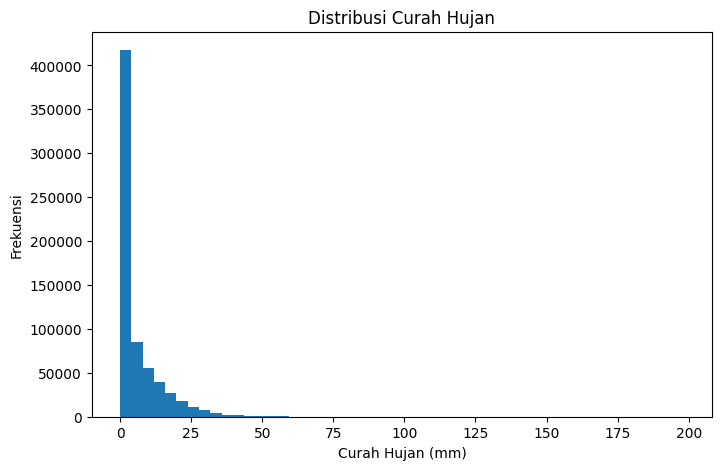

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['tp'].dropna(), bins=50)

plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Curah Hujan')
plt.show()

In [15]:
dataera5['tp'].describe()

count    672152.000000
mean          5.676781
std           8.480807
min           0.000000
25%           0.288963
50%           1.875018
75%           8.008131
max         198.232730
Name: tp, dtype: float64

In [16]:
dataera5['tp'] = dataera5['tp'].interpolate(
    method='linear',
    limit_direction='both'
)
dataera5

,datetime,latitude,longitude,tp,t2m,d2m,u10,v10
0,2016-01-01 00:00:00,-8.1,112.5,3.074169,297.59668,295.57446,-0.440109,0.633028
1,2016-01-01 00:00:00,-8.1,112.6,3.453136,298.23926,296.21118,-0.356613,0.687716
2,2016-01-01 00:00:00,-8.1,112.7,3.867984,298.30176,296.26000,-0.234543,0.770723
3,2016-01-01 00:00:00,-8.1,112.8,4.375398,295.53613,293.47680,-0.135910,0.847383
4,2016-01-01 00:00:00,-8.1,112.9,5.260855,293.10060,291.16820,-0.149582,0.888887
...,...,...,...,...,...,...,...,...
818267,2025-12-31 18:00:00,-7.5,112.8,8.154511,NaN,NaN,NaN,NaN
818268,2025-12-31 18:00:00,-7.5,112.9,8.154511,NaN,NaN,NaN,NaN
818269,2025-12-31 18:00:00,-7.5,113.0,8.154511,NaN,NaN,NaN,NaN
818270,2025-12-31 18:00:00,-7.5,113.1,8.154511,NaN,NaN,NaN,NaN


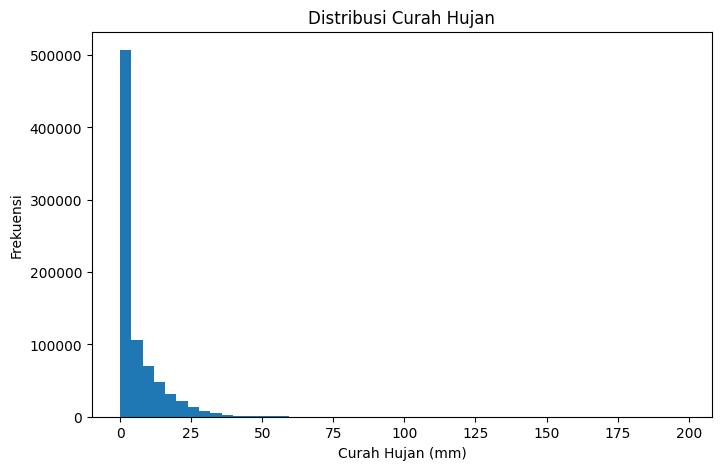

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['tp'].dropna(), bins=50)

plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Curah Hujan')
plt.show()

In [18]:
print(dataera5['tp'].isna().sum())

0


### TEMPERATURE


In [30]:
dataera5[dataera5['t2m'].isna()]

,datetime,latitude,longitude,tp,t2m,d2m,u10,v10


In [31]:
dataera5['t2m'] = dataera5['t2m'].interpolate(
    method='linear',
    limit_direction='both'
)

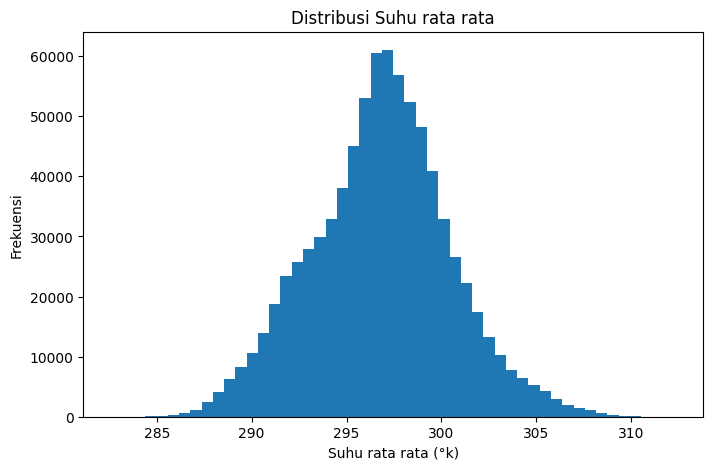

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['t2m'].dropna(), bins=50)

plt.xlabel('Suhu rata rata (°k)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Suhu rata rata')
plt.show()

In [35]:
dataera5['t2m'] = dataera5['t2m'] - 273.15

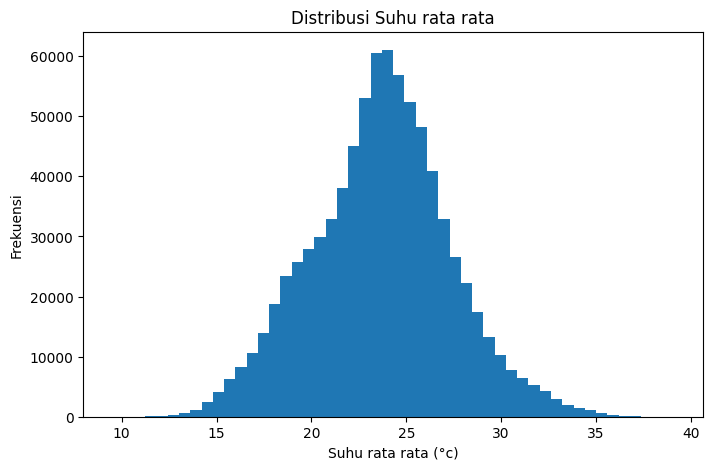

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['t2m'].dropna(), bins=50)

plt.xlabel('Suhu rata rata (°c)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Suhu rata rata')
plt.show()

### d2m

In [37]:
dataera5['d2m'].isna().sum()

np.int64(146120)

In [38]:
dataera5['d2m'].describe()

count    672152.000000
mean        293.157028
std           3.043057
min         275.990230
25%         291.187740
50%         293.600100
75%         295.528560
max         300.645260
Name: d2m, dtype: float64

In [39]:
dataera5['d2m'] = dataera5['d2m'] - 273.15

In [40]:
dataera5['d2m'].describe()

count    672152.000000
mean         20.007028
std           3.043057
min           2.840230
25%          18.037740
50%          20.450100
75%          22.378560
max          27.495260
Name: d2m, dtype: float64

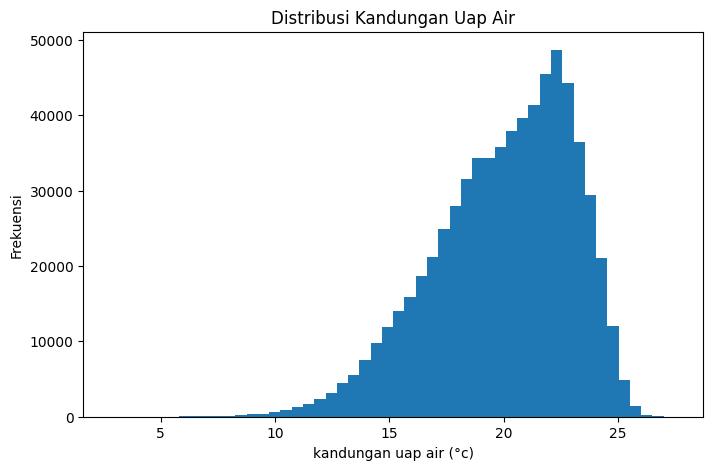

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['d2m'].dropna(), bins=50)

plt.xlabel('kandungan uap air (°c)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kandungan Uap Air')
plt.show()

In [42]:
dataera5['d2m'] = dataera5['d2m'].interpolate(
    method='linear',
    limit_direction='both'
)

In [43]:
dataera5['d2m'].isna().sum()

np.int64(0)

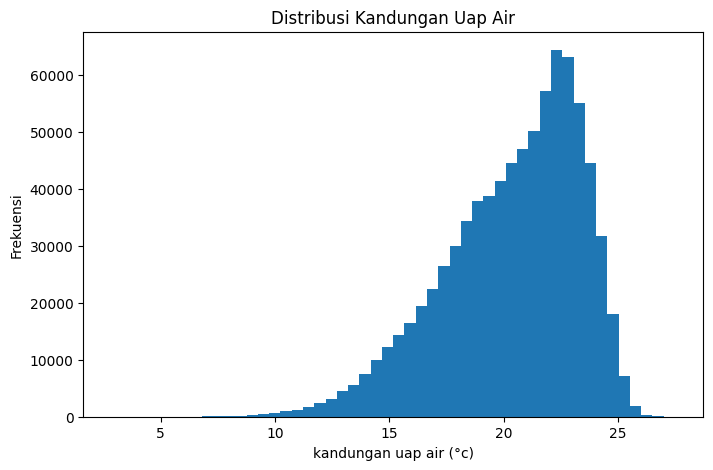

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['d2m'].dropna(), bins=50)

plt.xlabel('kandungan uap air (°c)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kandungan Uap Air')
plt.show()

### u10 → komponen angin timur–barat


In [45]:
dataera5['u10'].isna().sum()

np.int64(146120)

In [46]:
dataera5['u10'].describe()

count    672152.000000
mean         -0.229265
std           0.785722
min          -5.195221
25%          -0.673538
50%          -0.191574
75%           0.238799
max           4.962707
Name: u10, dtype: float64

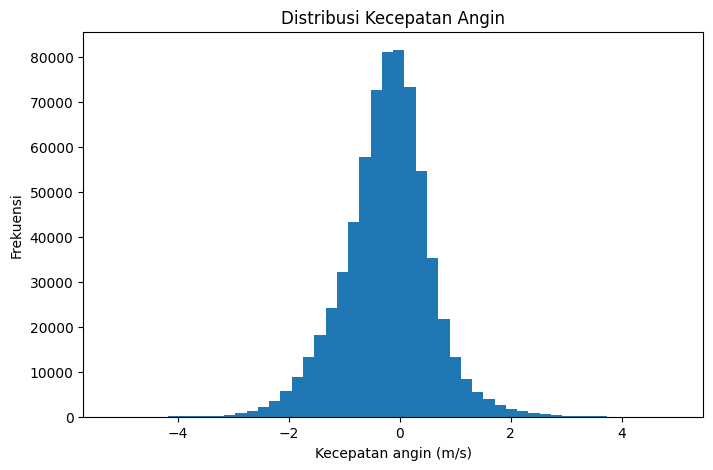

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['u10'].dropna(), bins=50)

plt.xlabel('Kecepatan angin (m/s)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kecepatan Angin')
plt.show()

In [49]:
dataera5['u10'] = dataera5['u10'].interpolate(
    method='linear',
    limit_direction='both'
)

In [50]:
dataera5['u10'].isna().sum()

np.int64(0)

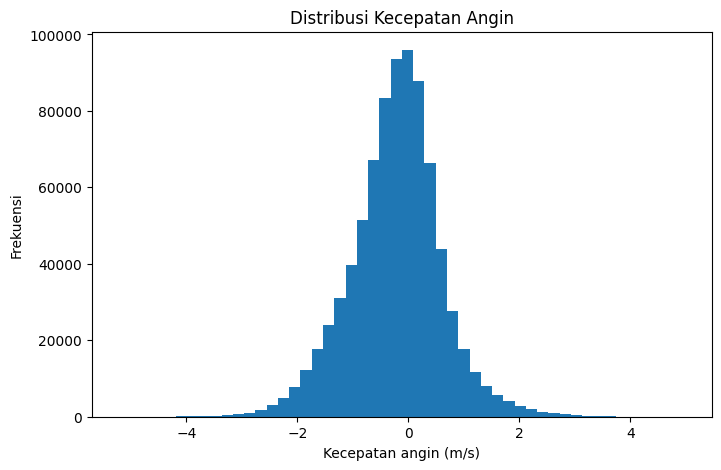

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['u10'].dropna(), bins=50)

plt.xlabel('Kecepatan angin (m/s)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kecepatan Angin')
plt.show()

### v10 → komponen angin utara–selatan

In [52]:
dataera5['v10'].isna().sum()

np.int64(146120)

In [53]:
dataera5['v10'].describe()

count    672152.000000
mean          0.319963
std           0.888339
min          -4.896668
25%          -0.251251
50%           0.372995
75%           0.898682
max           6.415390
Name: v10, dtype: float64

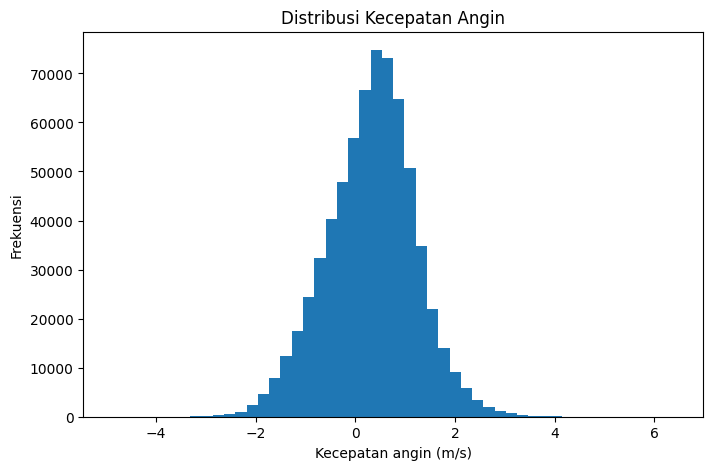

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['v10'].dropna(), bins=50)

plt.xlabel('Kecepatan angin (m/s)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kecepatan Angin')
plt.show()

In [55]:
dataera5['v10'] = dataera5['v10'].interpolate(
    method='linear',
    limit_direction='both'
)

In [56]:
dataera5['v10'].isna().sum()

np.int64(0)

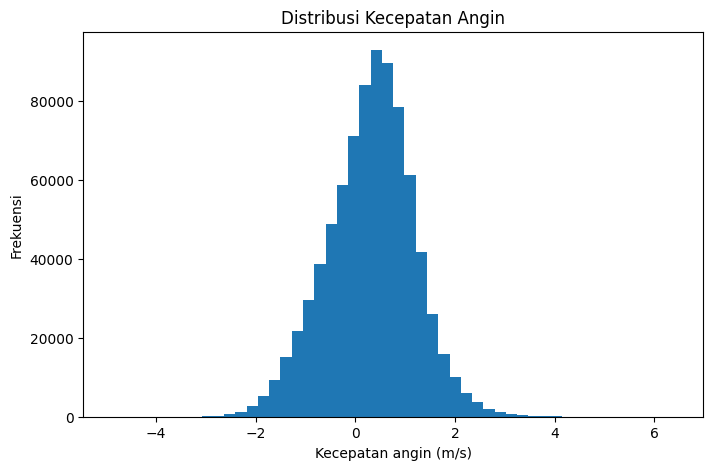

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataera5['v10'].dropna(), bins=50)

plt.xlabel('Kecepatan angin (m/s)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kecepatan Angin')
plt.show()

In [58]:
nan_rows = dataera5[
    dataera5[['tp', 't2m', 'd2m', 'u10', 'v10']]
    .isna()
    .any(axis=1)
]

nan_rows[['datetime']]

,datetime


In [59]:
dataera5.describe()

,latitude,longitude,tp,t2m,d2m,u10,v10
count,818272.0,818272.000000,818272.000000,818272.000000,818272.000000,818272.000000,818272.000000
mean,-7.8,112.850000,5.592039,23.671837,20.376884,-0.224257,0.307583
std,0.2,0.229129,8.312087,3.672470,2.994315,0.826038,0.871155
min,-8.1,112.500000,0.000000,9.454980,2.840230,-5.195221,-4.896668
25%,-8.0,112.675000,0.272075,21.302640,18.474361,-0.698578,-0.247105
50%,-7.8,112.850000,1.877718,23.768460,20.925200,-0.183578,0.360484
75%,-7.6,113.025000,7.957092,25.983540,22.696217,0.262829,0.879975
max,-7.5,113.200000,198.232730,39.162000,27.495260,4.962707,6.415390


In [60]:
dataera5.isnull().sum()

datetime     0
latitude     0
longitude    0
tp           0
t2m          0
d2m          0
u10          0
v10          0
dtype: int64

In [61]:
dataera5.to_csv(
    r'C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_final\data_era5_bersih.csv',
    index=False
)

# IOD DAN ENSO


In [86]:
import numpy as np
import pandas as pd


In [87]:
data_IOD = pd.read_csv(r"C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_merge\enso_iod_2016_2025.csv")

In [88]:
data_IOD

,year,month,oni_anomaly,dmi_iod
0,2016,1,2.63,0.266
1,2016,2,2.28,-0.110
2,2016,3,1.71,-0.009
3,2016,4,1.05,0.146
4,2016,5,0.49,-0.113
...,...,...,...,...
115,2025,8,-0.28,NaN
116,2025,9,-0.40,NaN
117,2025,10,-0.51,NaN
118,2025,11,-0.55,NaN


In [89]:
data_IOD.isnull().sum()

year           0
month          0
oni_anomaly    0
dmi_iod        8
dtype: int64

In [90]:
# Isi NaN dmi_iod dengan rata-rata berdasarkan bulan yang sama
data_IOD['dmi_iod'] = data_IOD['dmi_iod'].fillna(
    data_IOD.groupby('month')['dmi_iod'].transform('mean')
)

In [91]:
data_IOD

,year,month,oni_anomaly,dmi_iod
0,2016,1,2.63,0.266000
1,2016,2,2.28,-0.110000
2,2016,3,1.71,-0.009000
3,2016,4,1.05,0.146000
4,2016,5,0.49,-0.113000
...,...,...,...,...
115,2025,8,-0.28,0.114111
116,2025,9,-0.40,0.176111
117,2025,10,-0.51,0.132556
118,2025,11,-0.55,0.177667


In [92]:
data_IOD.describe()

,year,month,oni_anomaly,dmi_iod
count,120.000000,120.000000,120.000000,120.000000
mean,2020.500000,6.500000,0.029000,0.150639
std,2.884324,3.466527,0.814621,0.348937
min,2016.000000,1.000000,-1.200000,-0.758000
25%,2018.000000,3.750000,-0.585000,-0.087250
50%,2020.500000,6.500000,-0.135000,0.118500
75%,2023.000000,9.250000,0.522500,0.364500
max,2025.000000,12.000000,2.630000,0.964000


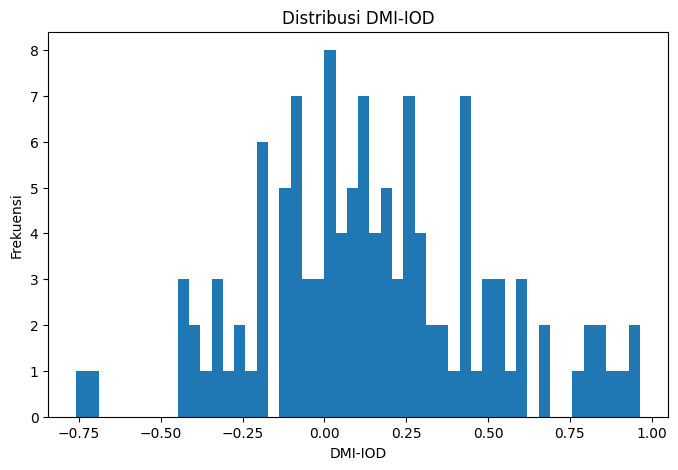

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data_IOD['dmi_iod'].dropna(), bins=50)

plt.xlabel('DMI-IOD')
plt.ylabel('Frekuensi')
plt.title('Distribusi DMI-IOD')
plt.show()

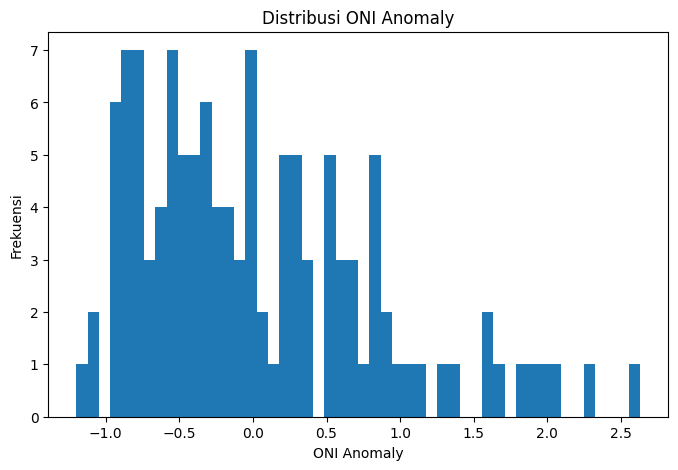

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data_IOD['oni_anomaly'].dropna(), bins=50)

plt.xlabel('ONI Anomaly')
plt.ylabel('Frekuensi')
plt.title('Distribusi ONI Anomaly')
plt.show()

In [95]:
data_IOD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         120 non-null    int64  
 1   month        120 non-null    int64  
 2   oni_anomaly  120 non-null    float64
 3   dmi_iod      120 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 3.9 KB


In [96]:
data_IOD.to_csv(
    r'C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_final\data_IOD_ENSO_bersih.csv',
    index=False
)

# SST

In [97]:
data_SST = pd.read_csv(r"C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_merge\sst_pasuruan_2016-2025_merged.csv")

In [98]:
data_SST.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3647 entries, 0 to 3646
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datetime   3647 non-null   object 
 1   zlev       3647 non-null   float64
 2   latitude   3647 non-null   float64
 3   longitude  3647 non-null   float64
 4   sst        3647 non-null   float64
dtypes: float64(4), object(1)
memory usage: 142.6+ KB


In [99]:
data_SST['datetime'] = pd.to_datetime(data_SST['datetime'])

In [100]:
data_SST.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3647 entries, 0 to 3646
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   datetime   3647 non-null   datetime64[ns, UTC]
 1   zlev       3647 non-null   float64            
 2   latitude   3647 non-null   float64            
 3   longitude  3647 non-null   float64            
 4   sst        3647 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 142.6 KB


In [101]:
data_SST.to_csv(
    r'C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_final\data_SST_bersih.csv',
    index=False
)